# Benchmark: Neighbourhood-Size Diagnostics for Local Injectivity

The standard pixel Jacobian determinant $J_{\det} > 0$ is a **necessary but not sufficient** condition for a discrete DVF's continuous extension to be locally injective.  Because $J_{\det}$ is evaluated at pixel centres using central differences, it is only a statement at the *samples themselves* — it says nothing about the bilinear interpolant between samples, which can fold even when every corner Jdet is positive. The inadequacy of sample-point Jdet as an injectivity criterion in discrete deformation fields is discussed at length by Karaçalı & Davatzikos [3] and Choi & Lee [4].

This notebook computes two companion quality maps that address the sub-pixel gap:

1. **Per-pixel IFT neighbourhood radius** — lower bound on the size of the neighbourhood where the deformation is provably injective. The classical inverse-function theorem [1, Thm. 9.24] guarantees the existence of such a neighbourhood but not its size; the *quantitative* IFT [2, §3.2] gives the explicit bound
   $$r(x) \;\gtrsim\; \frac{\sigma_{\min}(I + \nabla u)}{2\, \|\nabla^2 u\|}$$
   Large $r$ ⇒ large certified-invertible neighbourhood.  Small $r$ ⇒ IFT guarantee shrinks toward a point, even if pixel-Jdet is positive.

2. **Per-cell minimum bilinear Jdet** — the Jdet of the bilinear interpolant restricted to one quad is biaffine in $(\alpha, \beta) \in [0,1]^2$, so its minimum is attained at a corner and has a closed form. This is the 2D specialisation of the isoparametric-element invertibility analysis in Ciarlet [5, §4.3]; the 3D trilinear analog is worked out by Ushakova [6].  $\min_Q J_{\det} > 0$ **certifies sub-pixel injectivity** over the entire cell — something pixel-Jdet alone cannot do.

## Analyses
1. Per-case side-by-side maps: pixel Jdet, IFT radius, cell min-Jdet
2. Pooled histograms of each quantity
3. **Diagnostic disagreement** — count cells where pixel Jdet is positive at all 4 corners yet cell min-Jdet is negative (the bowtie failure mode)
4. Summary table across all test cases

See the **References** section at the end of the notebook for bibliographic details.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from dvfopt import jacobian_det2D, iterative_serial
from dvfopt.jacobian import ift_radius_2d, cell_min_jdet_2d
from test_cases import (
    SYNTHETIC_CASES,
    RANDOM_DVF_CASES,
    make_deformation,
    make_random_dvf,
)
from benchmark_utils import (
    get_output_dir, save_summary_json,
    log_run_header, show_and_save, reset_figure_counter,
)


In [2]:
METHOD = "diagnostics"
NOTEBOOK_NAME = "neighborhood-injectivity"
OUTPUT_DIR = get_output_dir(METHOD, NOTEBOOK_NAME, base="../output")
reset_figure_counter()
summary = log_run_header(METHOD, NOTEBOOK_NAME, OUTPUT_DIR)

  Benchmark  : neighborhood-injectivity
  Method     : diagnostics
  Timestamp  : 2026-04-16T20:43:07
  Output dir : ..\output\diagnostics\neighborhood-injectivity


## Data collection

For each test case, compute three spatial maps on the **initial** (uncorrected) DVF:
- `jac`        — `(H, W)` central-difference pixel Jdet
- `ift_r`      — `(H, W)` per-pixel IFT radius lower bound
- `cell_min`   — `(H-1, W-1)` per-cell minimum bilinear Jdet

In [3]:
def collect_maps(deformation, label):
    """Compute the three injectivity diagnostic maps for one DVF."""
    phi = np.stack([deformation[1, 0], deformation[2, 0]])  # (2, H, W): [dy, dx]
    jac      = np.squeeze(jacobian_det2D(phi))              # (H, W)
    ift_r    = ift_radius_2d(phi)                           # (H, W)
    cell_min = cell_min_jdet_2d(phi)                        # (H-1, W-1)
    return {
        "label": label,
        "dvf": deformation,
        "phi": phi,
        "jac": jac,
        "ift_r": ift_r,
        "cell_min": cell_min,
    }


all_records = []

for key in SYNTHETIC_CASES:
    deformation, _, _ = make_deformation(key)
    label = SYNTHETIC_CASES[key]["title"]
    print(f"Collecting: {label}")
    all_records.append(collect_maps(deformation, label))

for key in RANDOM_DVF_CASES:
    deformation = make_random_dvf(key)
    label = RANDOM_DVF_CASES[key]["title"]
    print(f"Collecting: {label}")
    all_records.append(collect_maps(deformation, label))


Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Collecting: Case 1a — 10×10 crossing points
Building data for Laplacian Sparse Matrix A (optimized)


Creating Laplacian Sparse Matrix A


Collecting: Case 1b — 10×10 opposite
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


Collecting: Case 1c — 20×40 edges
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Collecting: Case 1d — 20×40 crossing points
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


Collecting: Case 3a — 10×10 opposites
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Collecting: Case 3b — 10×10 crossing points
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


Collecting: Case 3c — 20×20 opposites
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Collecting: Case 3d — 20×20 crossing points
Collecting: Case 1e — 20×20 spirals
Collecting: Case 1f — 20×20 random seed 42
Collecting: Case 3a — 10×10 spirals (seed 42)
Collecting: Case 3c — 20×20 spirals (seed 42)


---
## 1 — Per-case spatial maps

For each case, show the three diagnostic maps side by side.  Cell min-Jdet lives on a grid one cell smaller than the pixel maps; we inset it with zero-padding so the axes align visually.

**What to look for:** cells where pixel-Jdet panel (left) shows all-positive but cell-min-Jdet panel (right) shows negative values — these are the sub-pixel failure modes that the standard check misses.

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_01.png


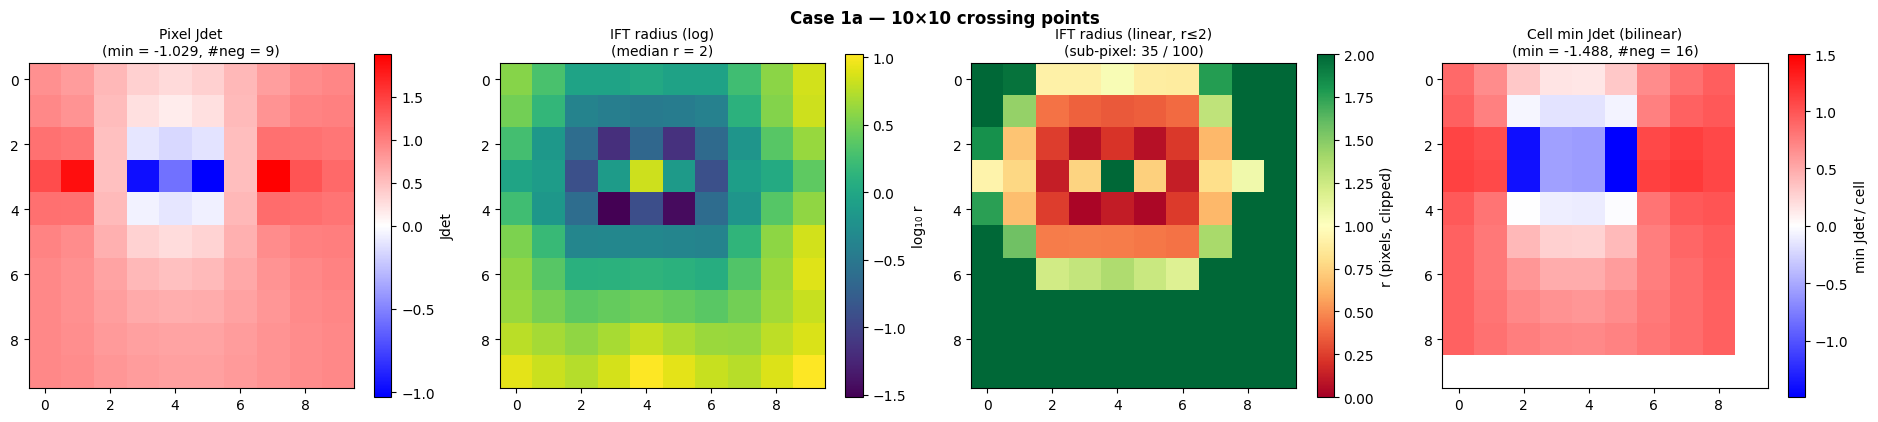

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_02.png


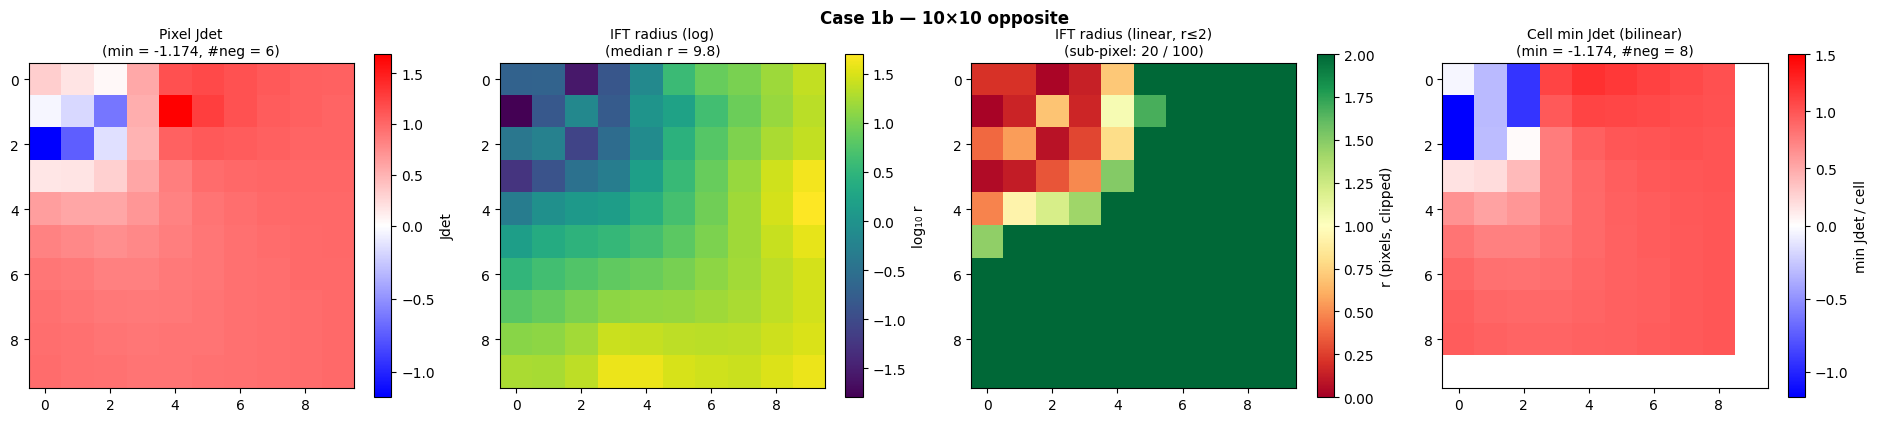

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_03.png


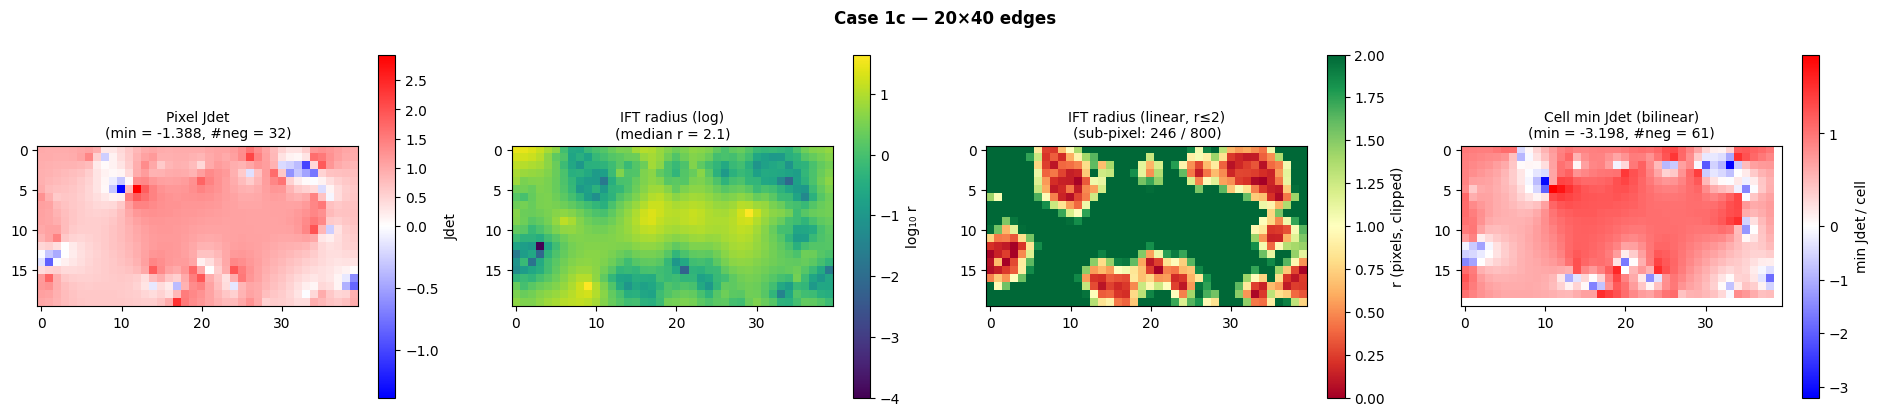

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_04.png


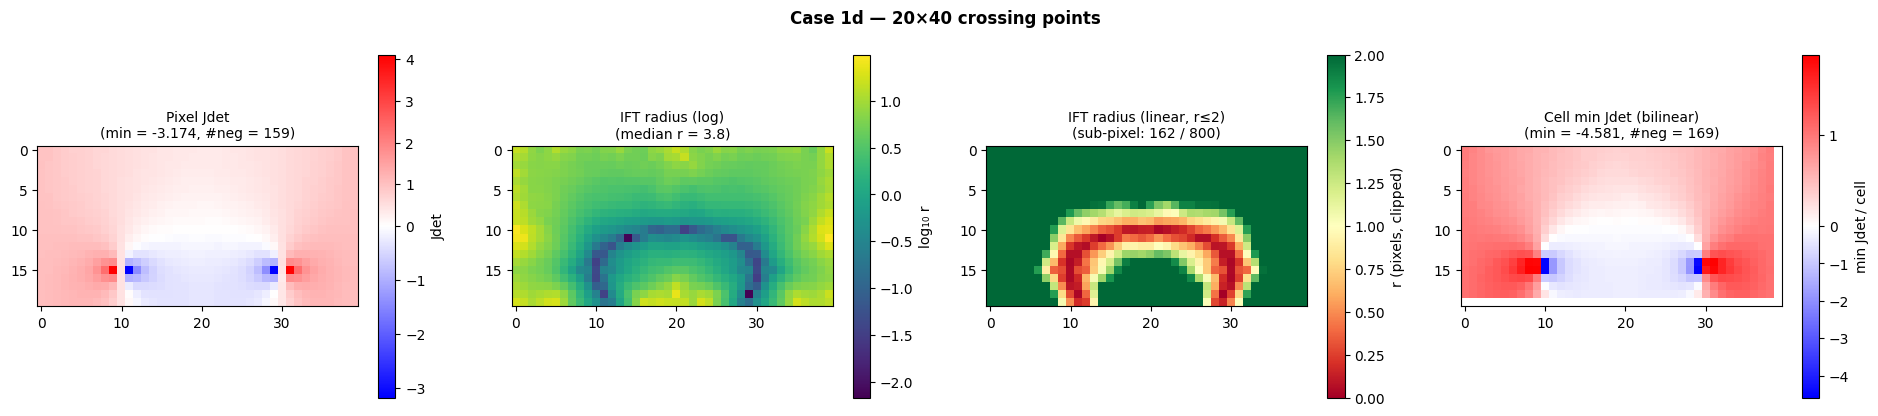

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_05.png


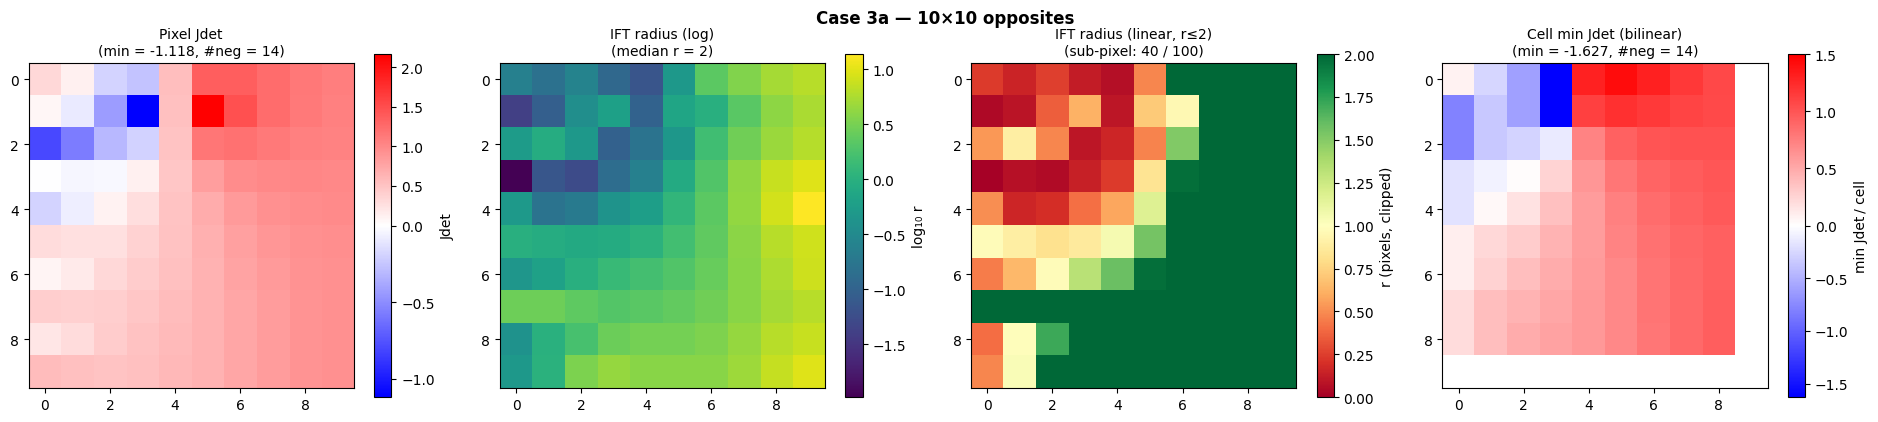

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_06.png


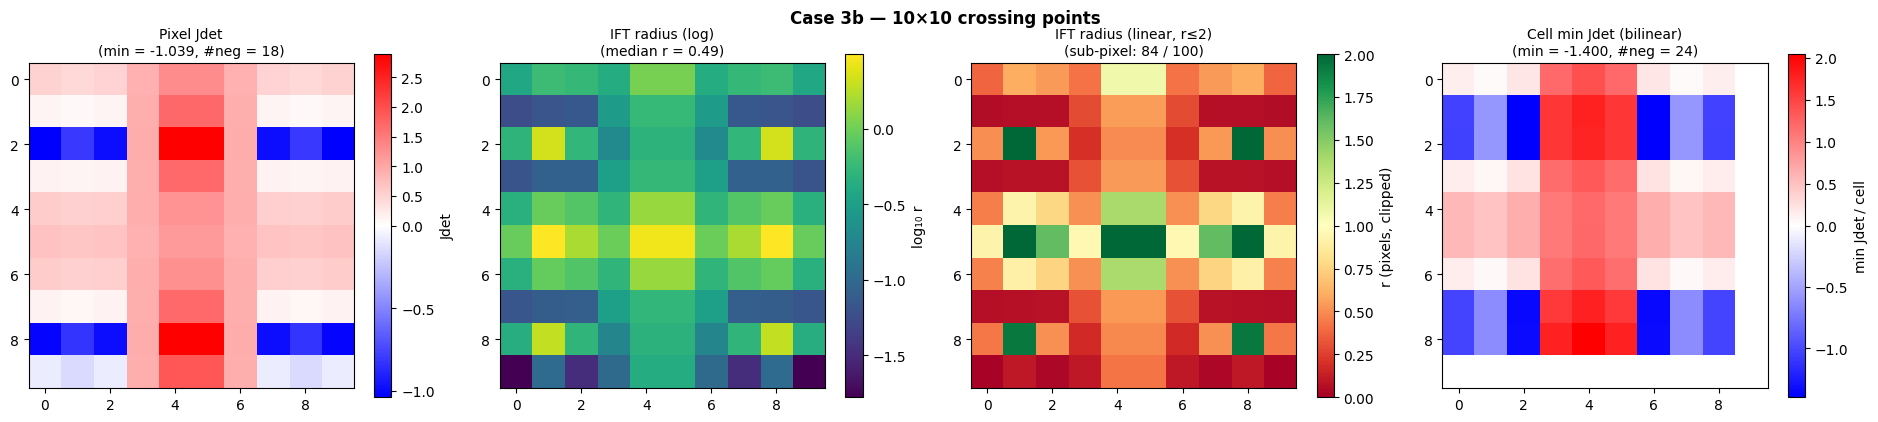

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_07.png


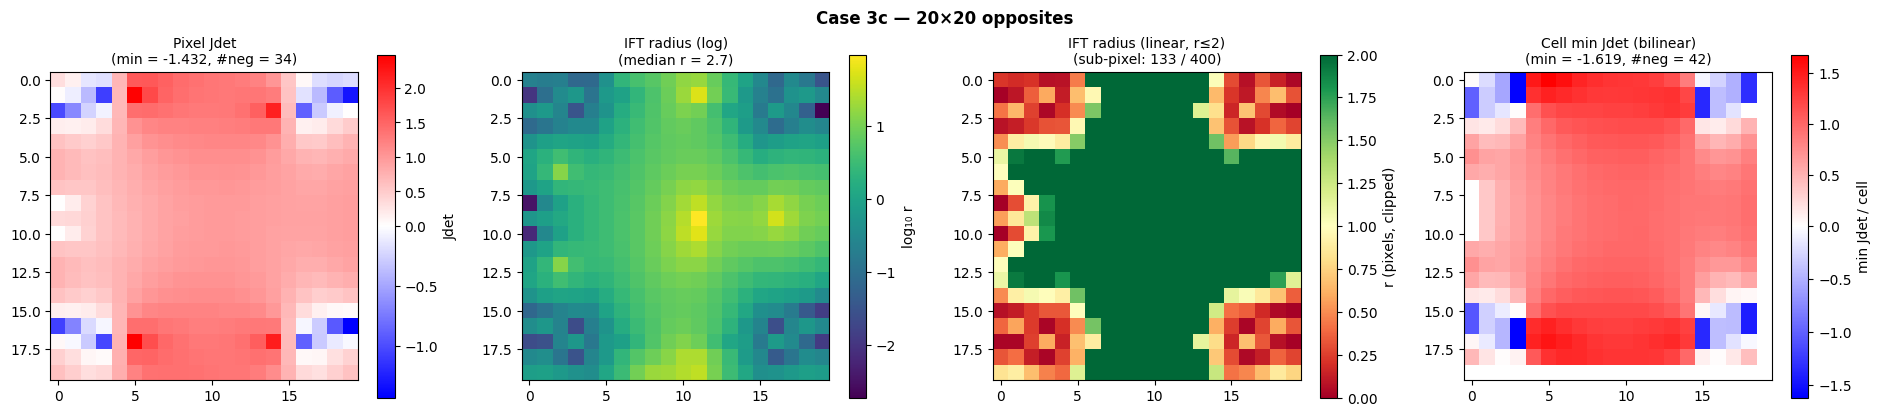

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_08.png


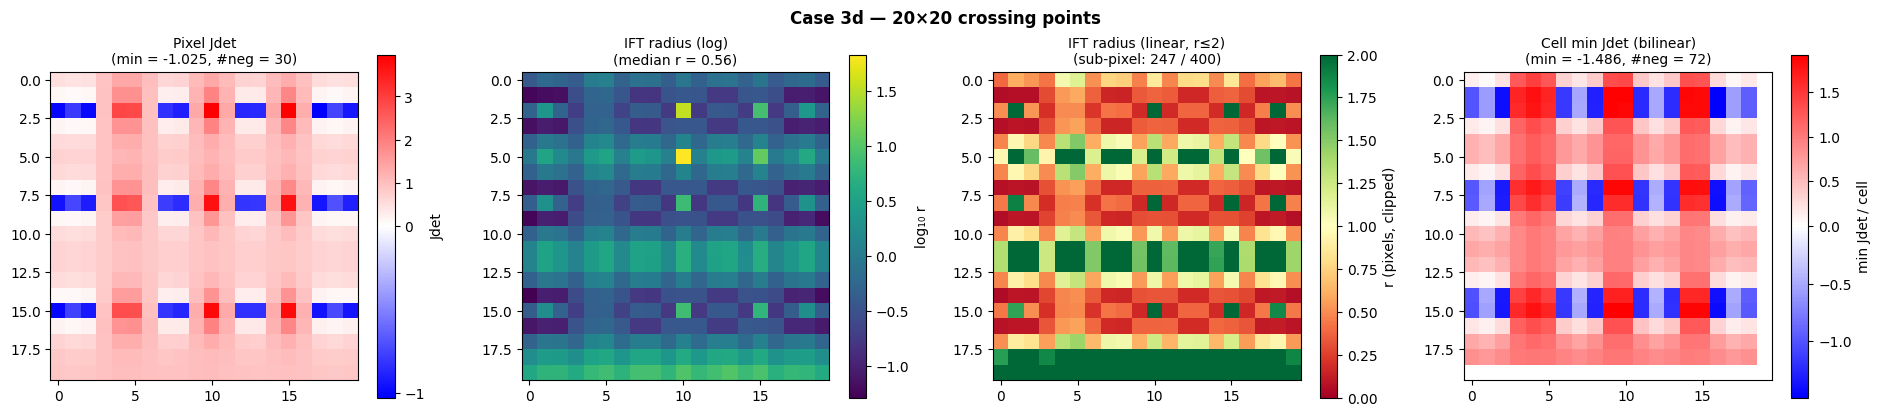

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_09.png


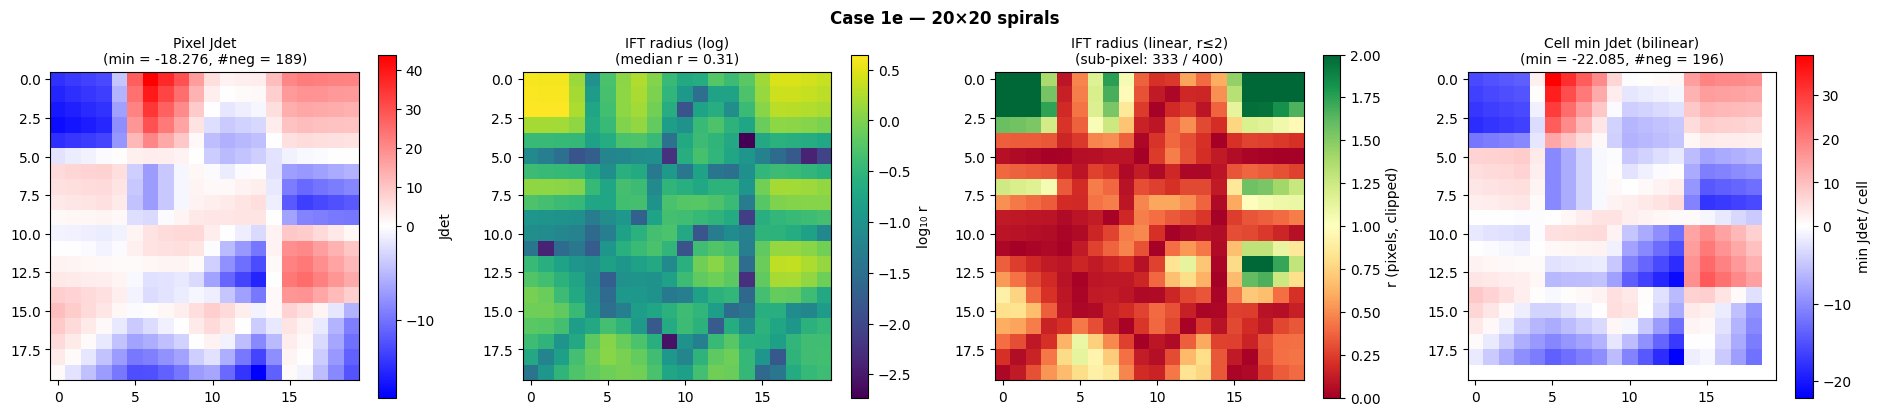

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_10.png


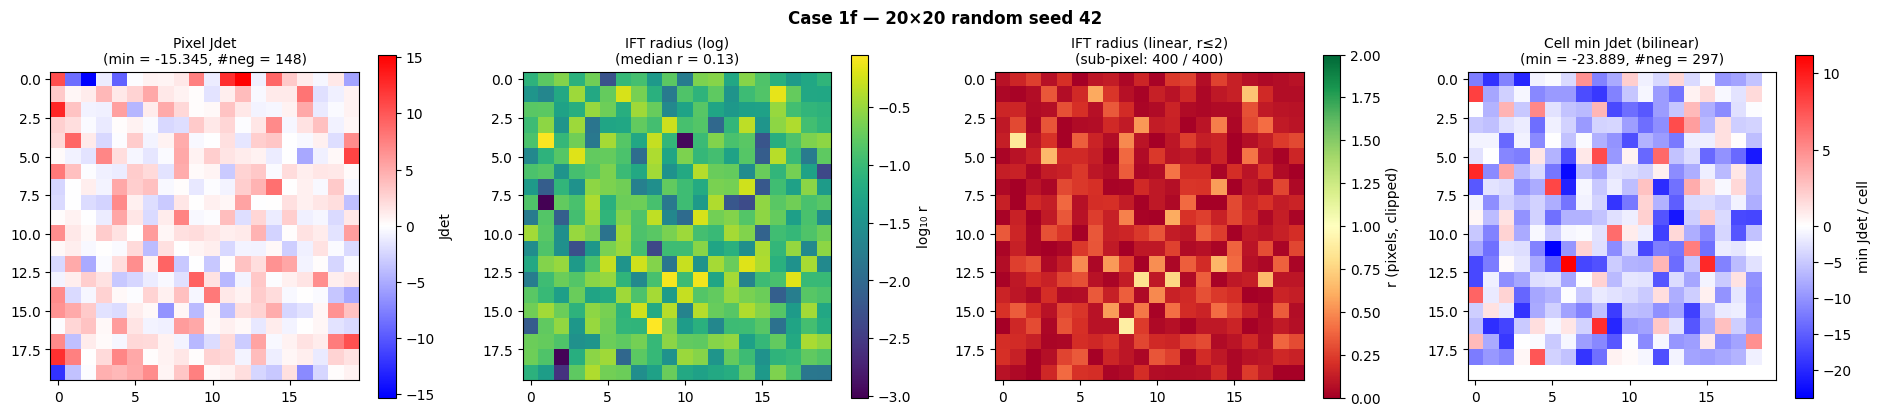

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_11.png


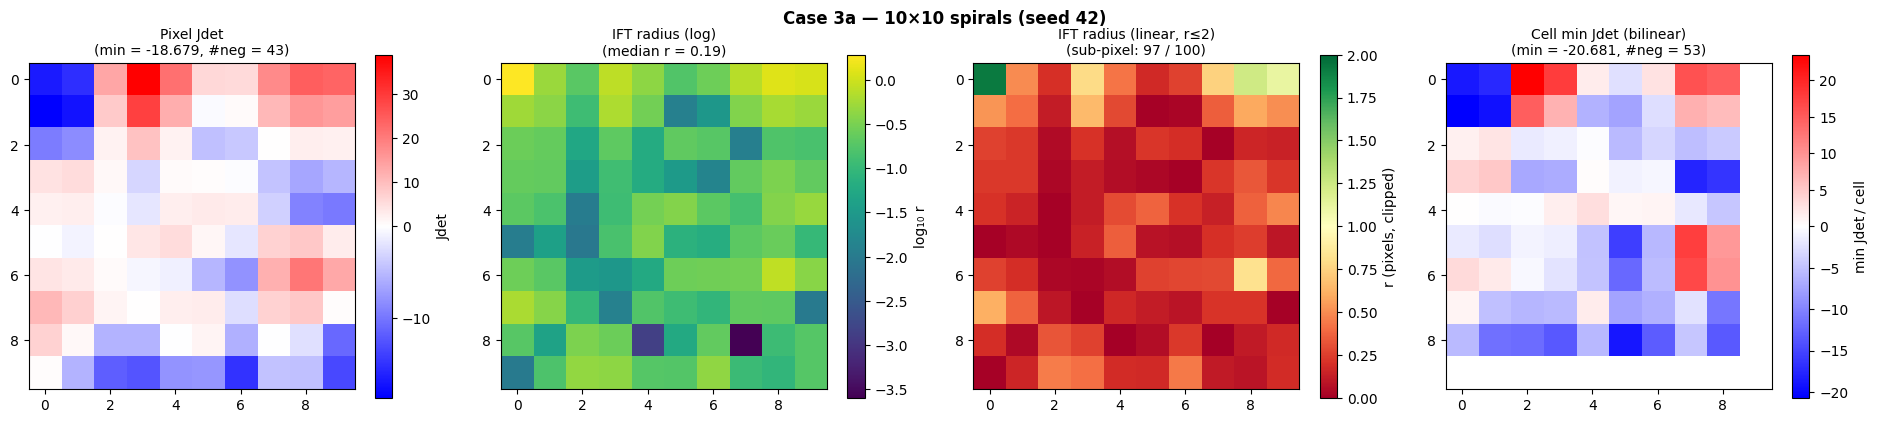

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_12.png


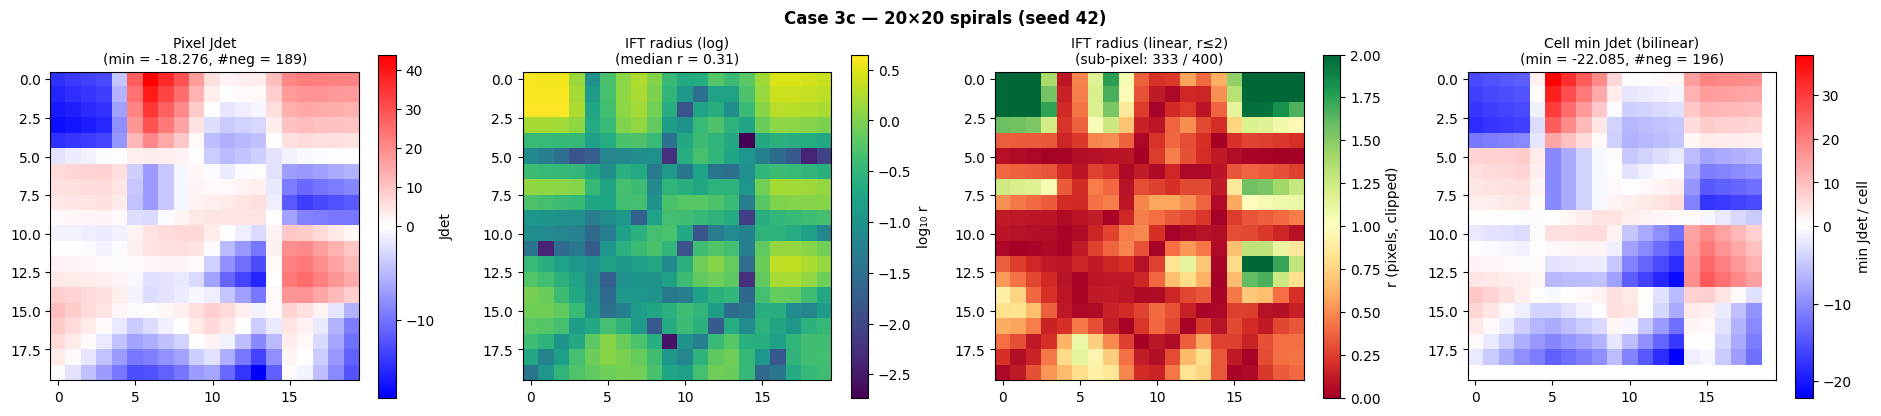

In [4]:
def _pad_cell_map(cell_map):
    """Embed an (H-1, W-1) cell map into (H, W) with NaN padding on last row/col."""
    Hm1, Wm1 = cell_map.shape
    out = np.full((Hm1 + 1, Wm1 + 1), np.nan)
    out[:-1, :-1] = cell_map
    return out


def _jdet_norm(arr, pad=0.5):
    vmin = min(float(np.nanmin(arr)), -pad)
    vmax = max(float(np.nanmax(arr)), 1.0 + pad)
    return mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)


for rec in all_records:
    jac      = rec["jac"]
    ift_r    = rec["ift_r"]
    cell_pad = _pad_cell_map(rec["cell_min"])

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))

    # Pixel Jdet
    im0 = axes[0].imshow(jac, cmap="bwr", norm=_jdet_norm(jac),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im0, ax=axes[0], label="Jdet")
    axes[0].set_title(f"Pixel Jdet\n(min = {jac.min():+.3f}, #neg = {(jac <= 0).sum()})",
                      fontsize=10)

    # IFT radius — log scale (global structure across many orders of magnitude)
    r_safe = np.clip(ift_r, 1e-4, None)
    im1 = axes[1].imshow(np.log10(r_safe), cmap="viridis",
                         origin="upper", interpolation="nearest")
    plt.colorbar(im1, ax=axes[1], label="log\u2081\u2080 r")
    axes[1].set_title(f"IFT radius (log)\n(median r = {np.median(ift_r):.2g})",
                      fontsize=10)

    # IFT radius — clipped-linear at [0, 2] pixels, diverging at r=1
    # Colormap break at r=1 answers "is this sample certified injective beyond
    # a pixel width?" — no sub-pixel contour line (r is a per-pixel quantity).
    r_clip = np.clip(ift_r, 0.0, 2.0)
    r_norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)
    im2 = axes[2].imshow(r_clip, cmap="RdYlGn", norm=r_norm,
                         origin="upper", interpolation="nearest")
    plt.colorbar(im2, ax=axes[2], label="r (pixels, clipped)")
    sub_pixel = int((ift_r < 1.0).sum())
    axes[2].set_title(f"IFT radius (linear, r\u22642)\n(sub-pixel: {sub_pixel} / {ift_r.size})",
                      fontsize=10)

    # Cell min-Jdet
    cm = rec["cell_min"]
    im3 = axes[3].imshow(cell_pad, cmap="bwr", norm=_jdet_norm(cm),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im3, ax=axes[3], label="min Jdet\u2009/ cell")
    axes[3].set_title(f"Cell min Jdet (bilinear)\n(min = {cm.min():+.3f}, #neg = {(cm <= 0).sum()})",
                      fontsize=10)

    fig.suptitle(rec["label"], fontsize=12, fontweight="bold")
    plt.tight_layout()
    show_and_save(OUTPUT_DIR)


---
## 2 — Pooled histograms

Distribution across all cases of the three quantities.  Dashed vertical line at 0 marks the fold / non-injectivity boundary.  The IFT radius is plotted on log-scale.

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_13.png


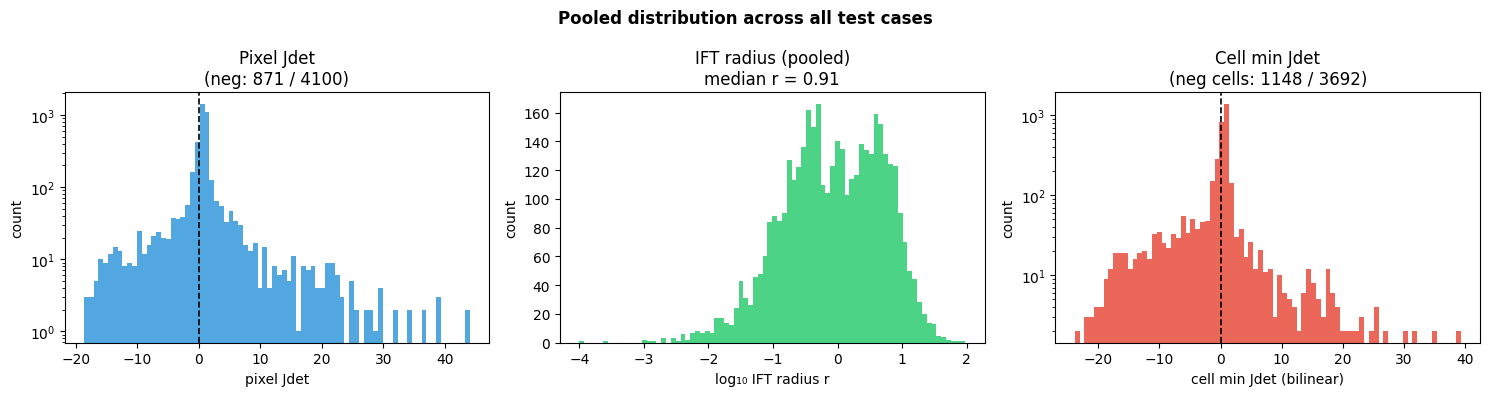

In [5]:
jac_pool      = np.concatenate([rec["jac"].ravel()      for rec in all_records])
ift_pool      = np.concatenate([rec["ift_r"].ravel()    for rec in all_records])
cell_min_pool = np.concatenate([rec["cell_min"].ravel() for rec in all_records])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(jac_pool, bins=80, color="#3498db", alpha=0.85)
axes[0].axvline(0, color="k", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("pixel Jdet")
axes[0].set_ylabel("count")
axes[0].set_title(f"Pixel Jdet\n(neg: {(jac_pool <= 0).sum()} / {jac_pool.size})")
axes[0].set_yscale("log")

ift_for_hist = np.clip(ift_pool, 1e-4, None)
axes[1].hist(np.log10(ift_for_hist), bins=80, color="#2ecc71", alpha=0.85)
axes[1].set_xlabel("log\u2081\u2080 IFT radius r")
axes[1].set_ylabel("count")
axes[1].set_title(f"IFT radius (pooled)\nmedian r = {np.median(ift_pool):.2g}")

axes[2].hist(cell_min_pool, bins=80, color="#e74c3c", alpha=0.85)
axes[2].axvline(0, color="k", linestyle="--", linewidth=1.2)
axes[2].set_xlabel("cell min Jdet (bilinear)")
axes[2].set_ylabel("count")
axes[2].set_title(f"Cell min Jdet\n(neg cells: {(cell_min_pool <= 0).sum()} / {cell_min_pool.size})")
axes[2].set_yscale("log")

fig.suptitle("Pooled distribution across all test cases", fontsize=12, fontweight="bold")
plt.tight_layout()
show_and_save(OUTPUT_DIR)

---
## 3 — Diagnostic disagreement: sub-pixel failures pixel-Jdet misses

For each cell, compare:
- **Corner-positivity**: are all 4 corner pixels' pixel-Jdets $\geq 0$?
- **Cell-positivity**: is $\min_Q J_{\det}^{\text{bilinear}} \geq 0$ ?

A cell with *corner-positive but cell-negative* is a sub-pixel fold hiding between pixels — exactly the failure mode motivated by the theory.

In [6]:
def corner_positive_mask(jac):
    """(H-1, W-1) boolean: all 4 pixel Jdets at the cell corners are > 0."""
    return ((jac[:-1, :-1] > 0) & (jac[:-1, 1:] > 0) &
            (jac[1:, :-1]  > 0) & (jac[1:, 1:]  > 0))


rows = []
for rec in all_records:
    jac   = rec["jac"]
    cmin  = rec["cell_min"]
    corner_pos = corner_positive_mask(jac)
    cell_pos   = cmin > 0

    n_cells        = cmin.size
    n_cell_neg     = int((~cell_pos).sum())
    n_corner_pos   = int(corner_pos.sum())
    n_hidden_fold  = int((corner_pos & ~cell_pos).sum())  # the interesting ones
    n_pixel_neg    = int((jac <= 0).sum())

    rows.append({
        "label": rec["label"],
        "n_pixels": jac.size,
        "n_pixel_neg": n_pixel_neg,
        "n_cells": n_cells,
        "n_cell_neg": n_cell_neg,
        "n_hidden_fold": n_hidden_fold,
    })

# Table
print(f"{'Case':<38s} {'pix-neg':>8s} {'cell-neg':>9s} {'hidden':>7s}")
print("-" * 66)
for r in rows:
    flag = "  <-- sub-pixel folds" if r["n_hidden_fold"] > 0 else ""
    print(f"  {r['label']:<36s} {r['n_pixel_neg']:>8d} {r['n_cell_neg']:>9d} {r['n_hidden_fold']:>7d}{flag}")

print("\n'hidden' = cells where all 4 corner pixel-Jdets are positive")
print("          yet the bilinear interpolant has negative Jdet in the cell interior.")

Case                                    pix-neg  cell-neg  hidden
------------------------------------------------------------------
  Case 1a — 10×10 crossing points             9        16       0
  Case 1b — 10×10 opposite                    6         8       0
  Case 1c — 20×40 edges                      32        61       4  <-- sub-pixel folds
  Case 1d — 20×40 crossing points           159       169       1  <-- sub-pixel folds
  Case 3a — 10×10 opposites                  14        14       0
  Case 3b — 10×10 crossing points            18        24       0
  Case 3c — 20×20 opposites                  34        42       0
  Case 3d — 20×20 crossing points            30        72       0
  Case 1e — 20×20 spirals                   189       196       1  <-- sub-pixel folds
  Case 1f — 20×20 random seed 42            148       297      34  <-- sub-pixel folds
  Case 3a — 10×10 spirals (seed 42)          43        53       0
  Case 3c — 20×20 spirals (seed 42)         189       196

---
## 4 — Visualise cases with sub-pixel (hidden) folds

For any case where `n_hidden_fold > 0`, plot:
- pixel Jdet (left)
- **hidden-fold mask**: cells flagged as corner-positive but interior-negative (centre)
- cell min Jdet (right)

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_14.png


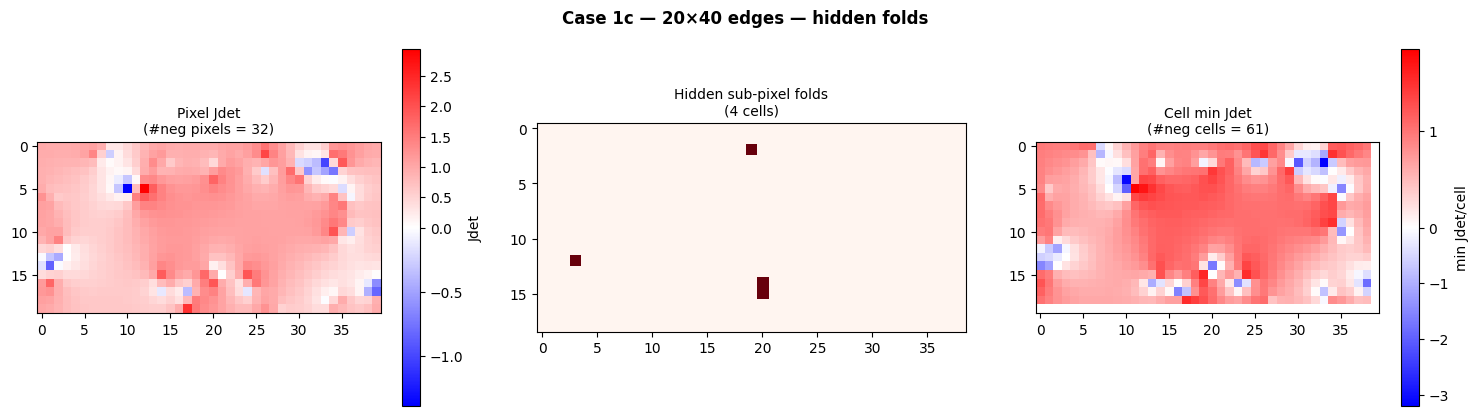

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_15.png


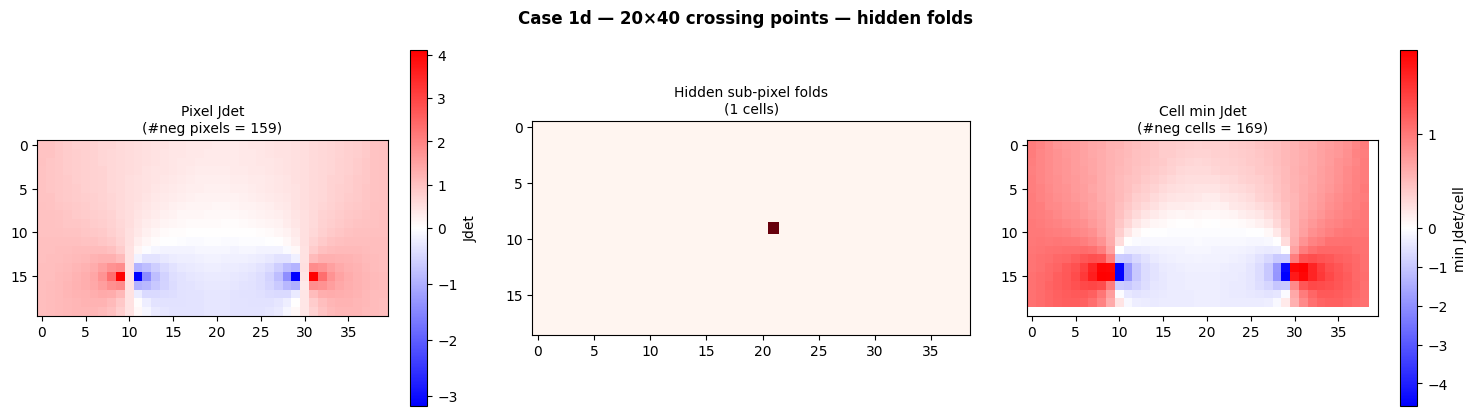

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_16.png


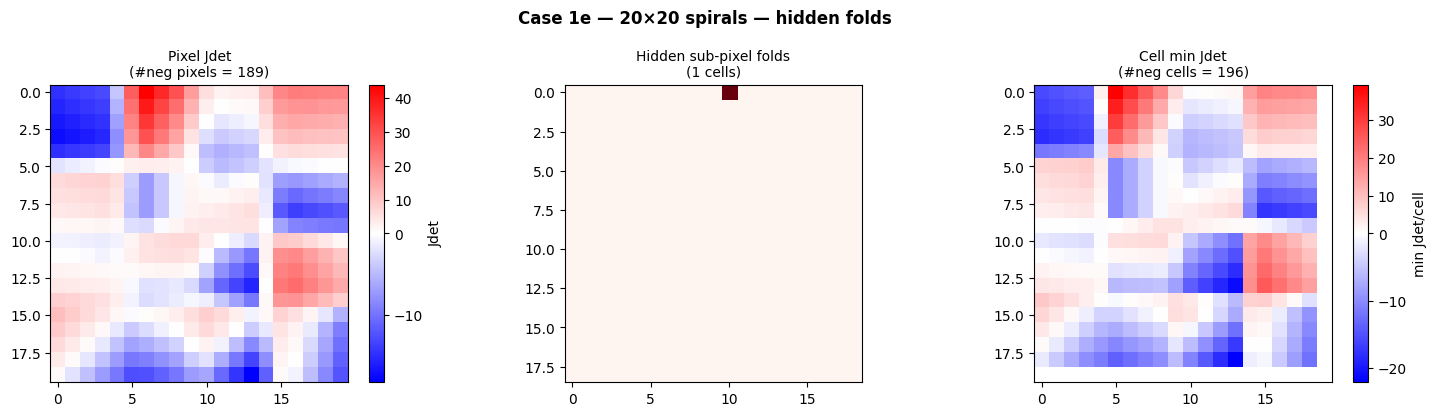

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_17.png


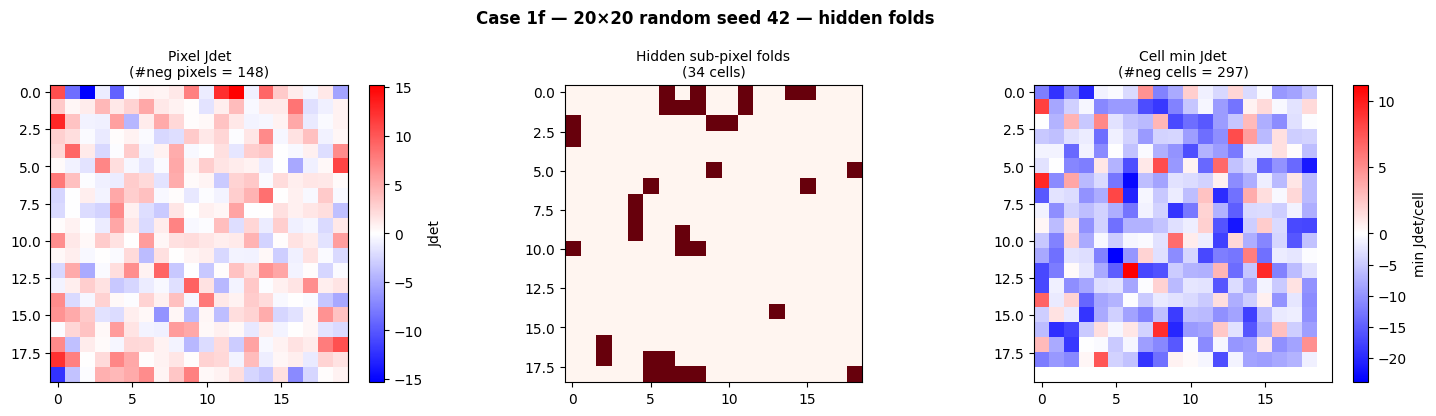

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_18.png


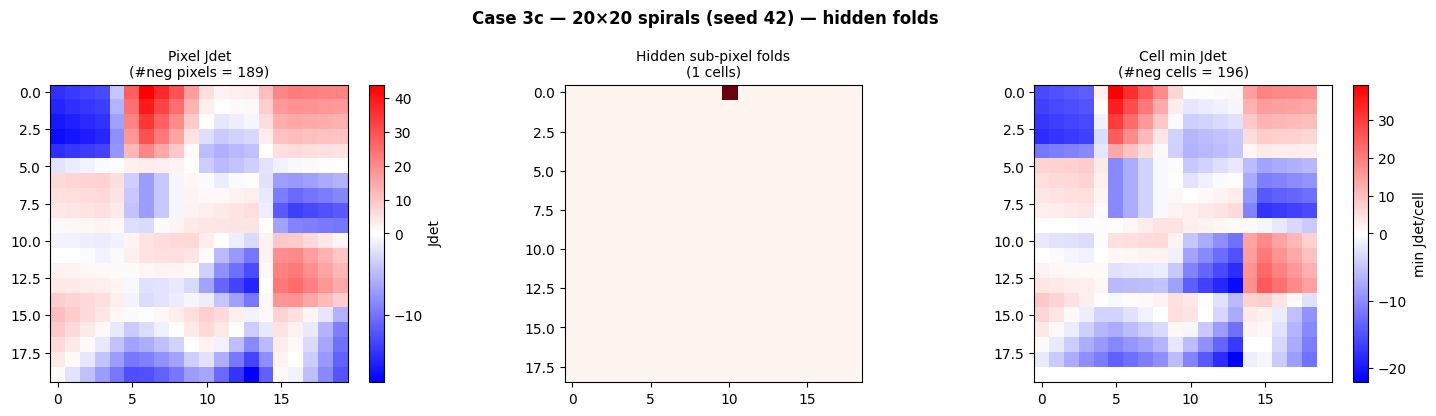

In [7]:
hidden_cases = [(rec, r) for rec, r in zip(all_records, rows) if r["n_hidden_fold"] > 0]

if not hidden_cases:
    print("No test case produced hidden sub-pixel folds — "
          "pixel-Jdet and bilinear cell-Jdet agree across this suite.")

for rec, r in hidden_cases:
    jac   = rec["jac"]
    cmin  = rec["cell_min"]
    corner_pos = corner_positive_mask(jac)
    hidden = corner_pos & (cmin <= 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

    im0 = axes[0].imshow(jac, cmap="bwr", norm=_jdet_norm(jac),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im0, ax=axes[0], label="Jdet")
    axes[0].set_title(f"Pixel Jdet\n(#neg pixels = {(jac <= 0).sum()})", fontsize=10)

    axes[1].imshow(hidden.astype(float), cmap="Reds", origin="upper",
                   interpolation="nearest", vmin=0, vmax=1)
    axes[1].set_title(f"Hidden sub-pixel folds\n({r['n_hidden_fold']} cells)",
                      fontsize=10)

    im2 = axes[2].imshow(_pad_cell_map(cmin), cmap="bwr", norm=_jdet_norm(cmin),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im2, ax=axes[2], label="min Jdet/cell")
    axes[2].set_title(f"Cell min Jdet\n(#neg cells = {(cmin <= 0).sum()})", fontsize=10)

    fig.suptitle(f"{rec['label']} \u2014 hidden folds", fontsize=12, fontweight="bold")
    plt.tight_layout()
    show_and_save(OUTPUT_DIR)

---
## 5 — Summary table and export

## Post-correction diagnostics

The standard pixel Jacobian determinant is what the SLSQP corrector targets — it drives every sample-point Jdet above the positivity threshold. But positivity at the pixel *samples* is strictly weaker than injectivity of the bilinearly-interpolated continuous field. Below we run `iterative_serial` on every test case and re-compute the three diagnostic maps on the corrected DVF. If the cell-min-Jdet or IFT-radius maps still light up after correction, that is direct evidence that "pixel-Jdet fully positive" ≠ "full local injectivity."


In [8]:
corrected_records = []
for rec in all_records:
    label = rec["label"]
    jac_init = rec["jac"]
    n_neg_init = int((jac_init <= 0).sum())
    if n_neg_init == 0:
        print(f"  [skip] {label}: already Jdet-positive")
        continue

    print(f"Correcting: {label}  (init neg = {n_neg_init})")
    phi_corr_full = iterative_serial(rec["dvf"].copy(), verbose=0)
    # iterative_serial returns a (2, H, W) [dy, dx] stack.
    phi_corr = np.asarray(phi_corr_full)
    if phi_corr.ndim == 4:
        phi_corr = np.stack([phi_corr[1, 0], phi_corr[2, 0]])

    jac_c     = np.squeeze(jacobian_det2D(phi_corr))
    ift_c     = ift_radius_2d(phi_corr)
    cell_c    = cell_min_jdet_2d(phi_corr)
    corrected_records.append({
        "label": label,
        "phi": phi_corr,
        "jac": jac_c,
        "ift_r": ift_c,
        "cell_min": cell_c,
        "n_neg_init": n_neg_init,
        "n_neg_final": int((jac_c <= 0).sum()),
        "n_cell_neg_init": int((rec["cell_min"] <= 0).sum()),
        "n_cell_neg_final": int((cell_c <= 0).sum()),
        "n_sub_pixel_init": int((rec["ift_r"] < 1.0).sum()),
        "n_sub_pixel_final": int((ift_c < 1.0).sum()),
    })

print(f"\nCorrected {len(corrected_records)} cases.")


Correcting: Case 1a — 10×10 crossing points  (init neg = 9)
Correcting: Case 1b — 10×10 opposite  (init neg = 6)
Correcting: Case 1c — 20×40 edges  (init neg = 32)


Correcting: Case 1d — 20×40 crossing points  (init neg = 159)


Correcting: Case 3a — 10×10 opposites  (init neg = 14)
Correcting: Case 3b — 10×10 crossing points  (init neg = 18)
Correcting: Case 3c — 20×20 opposites  (init neg = 34)
Correcting: Case 3d — 20×20 crossing points  (init neg = 30)
Correcting: Case 1e — 20×20 spirals  (init neg = 189)


Correcting: Case 1f — 20×20 random seed 42  (init neg = 148)


Correcting: Case 3a — 10×10 spirals (seed 42)  (init neg = 43)
Correcting: Case 3c — 20×20 spirals (seed 42)  (init neg = 189)



Corrected 12 cases.


---


  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_19.png


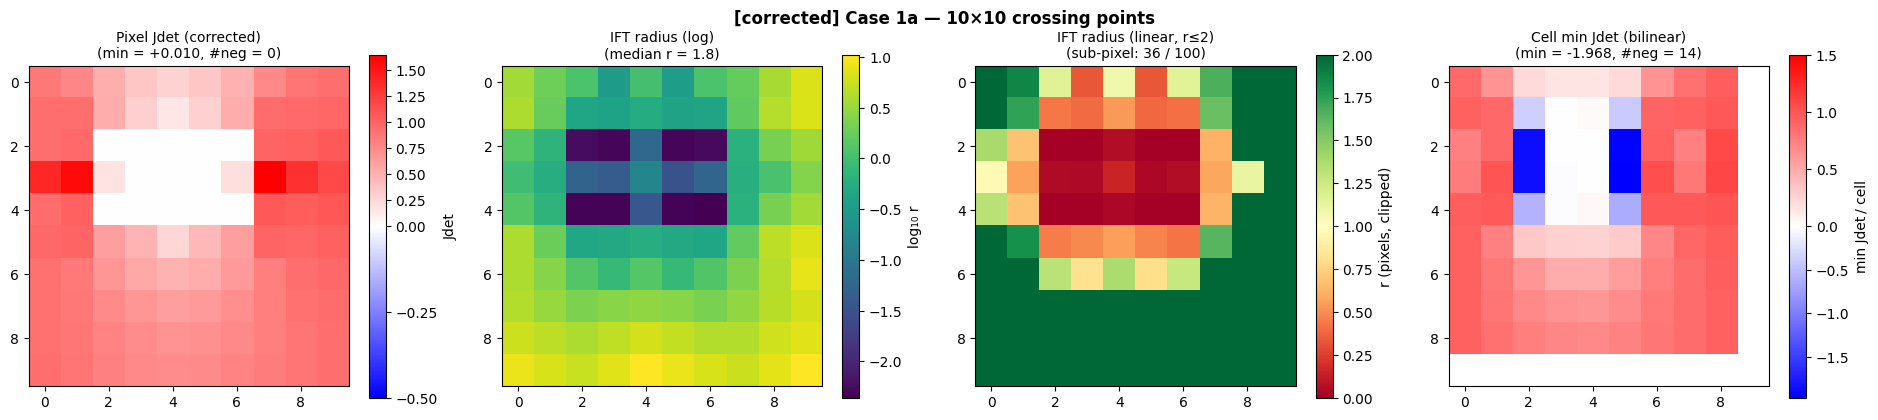

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_20.png


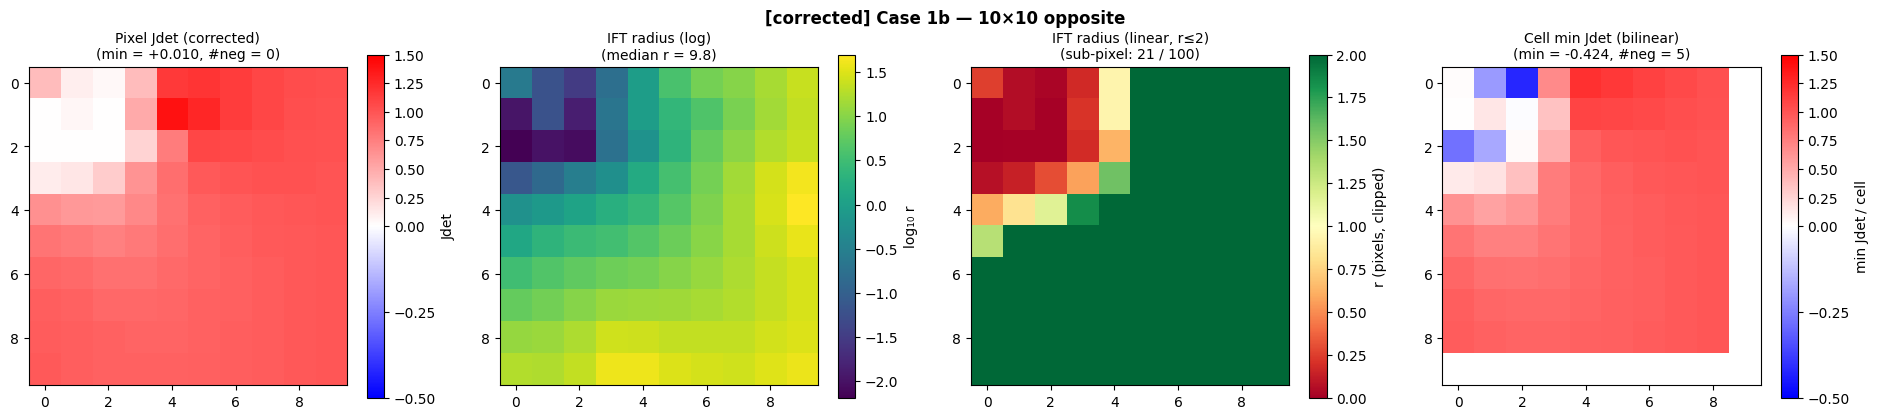

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_21.png


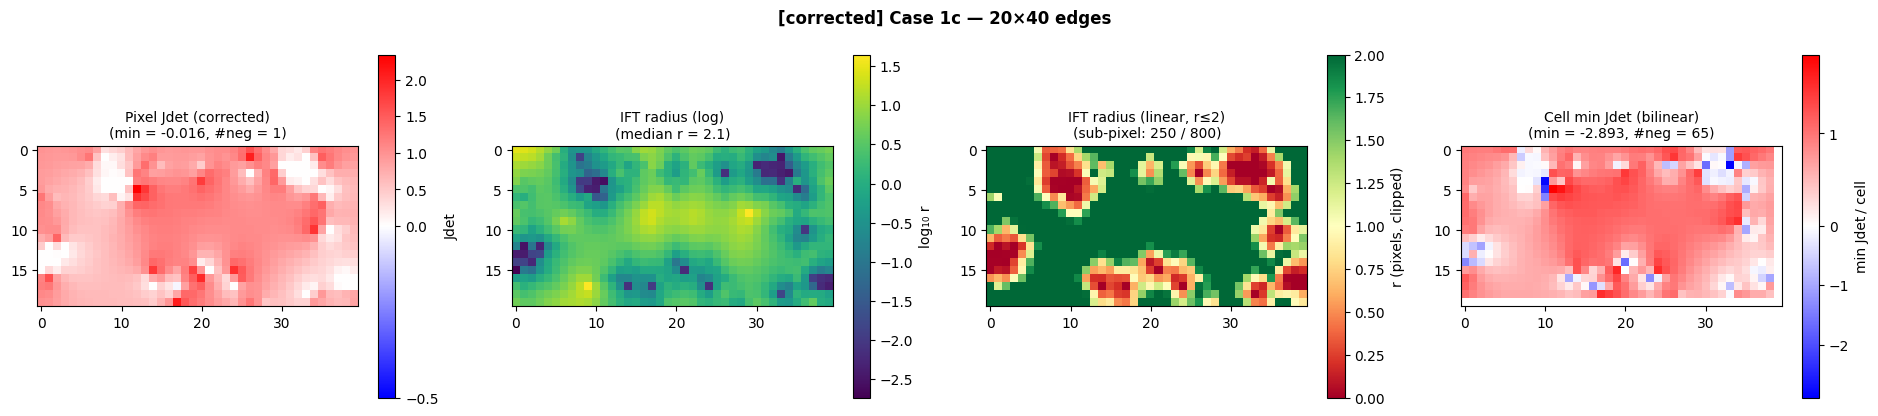

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_22.png


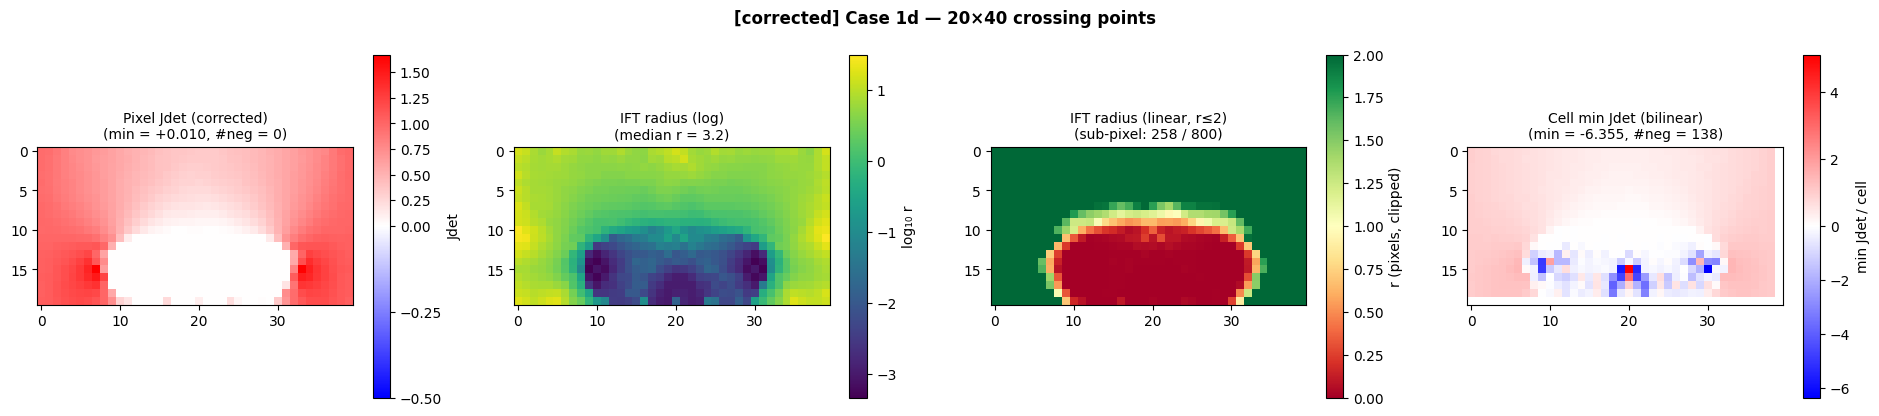

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_23.png


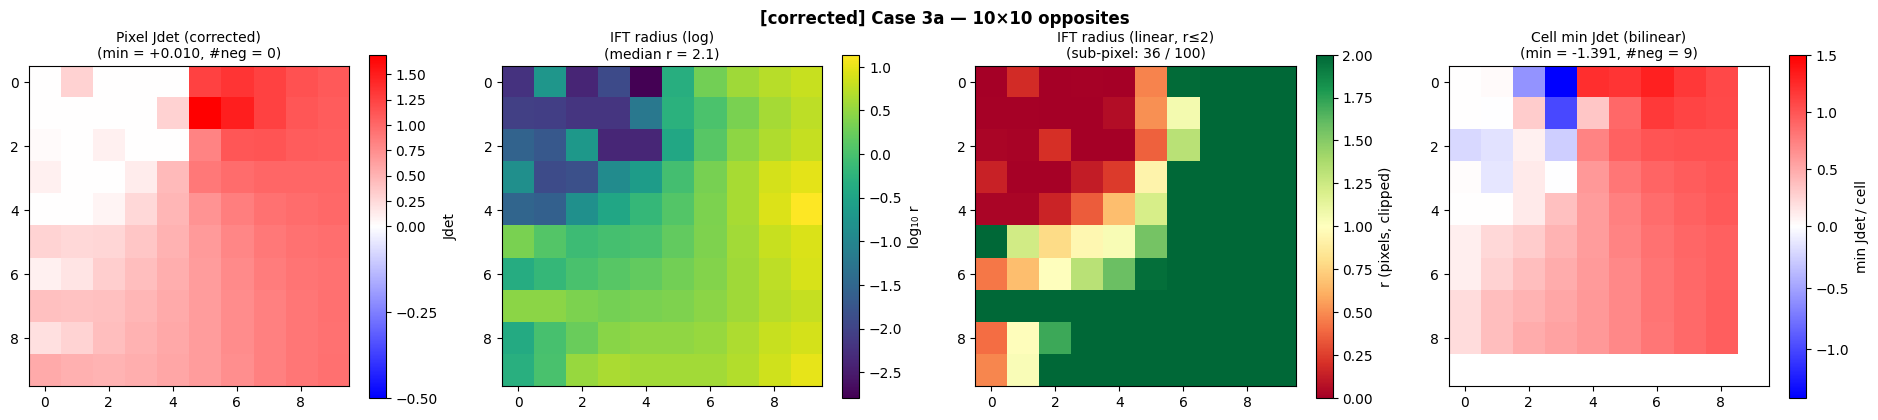

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_24.png


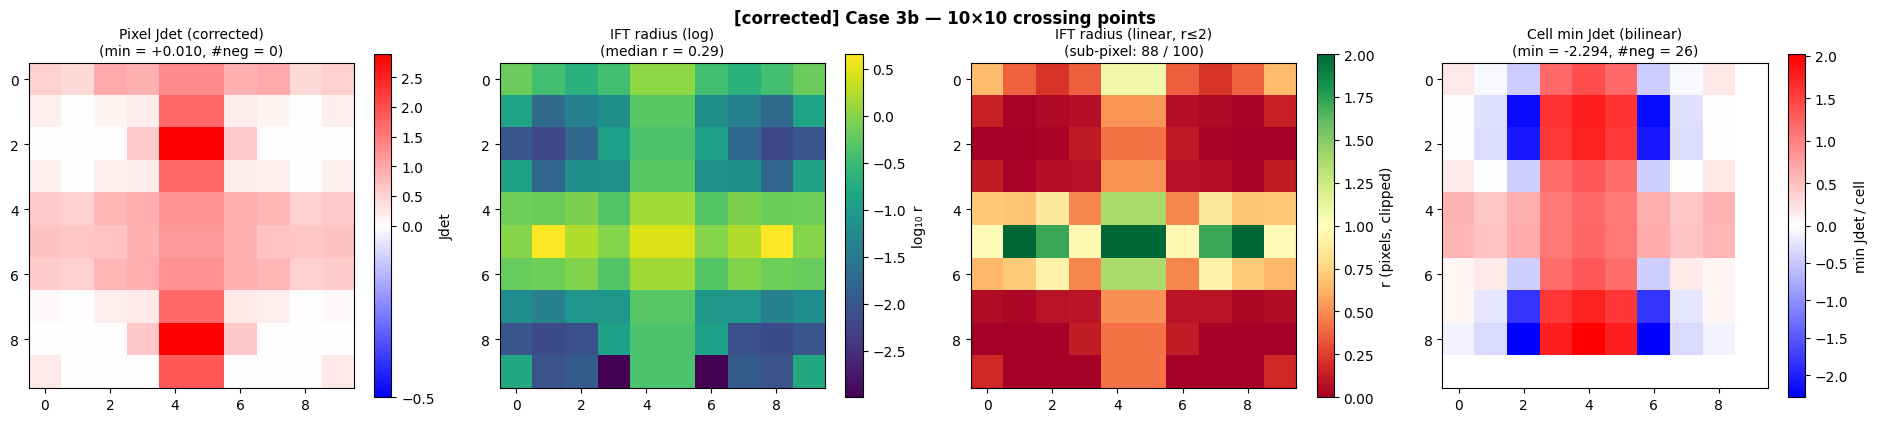

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_25.png


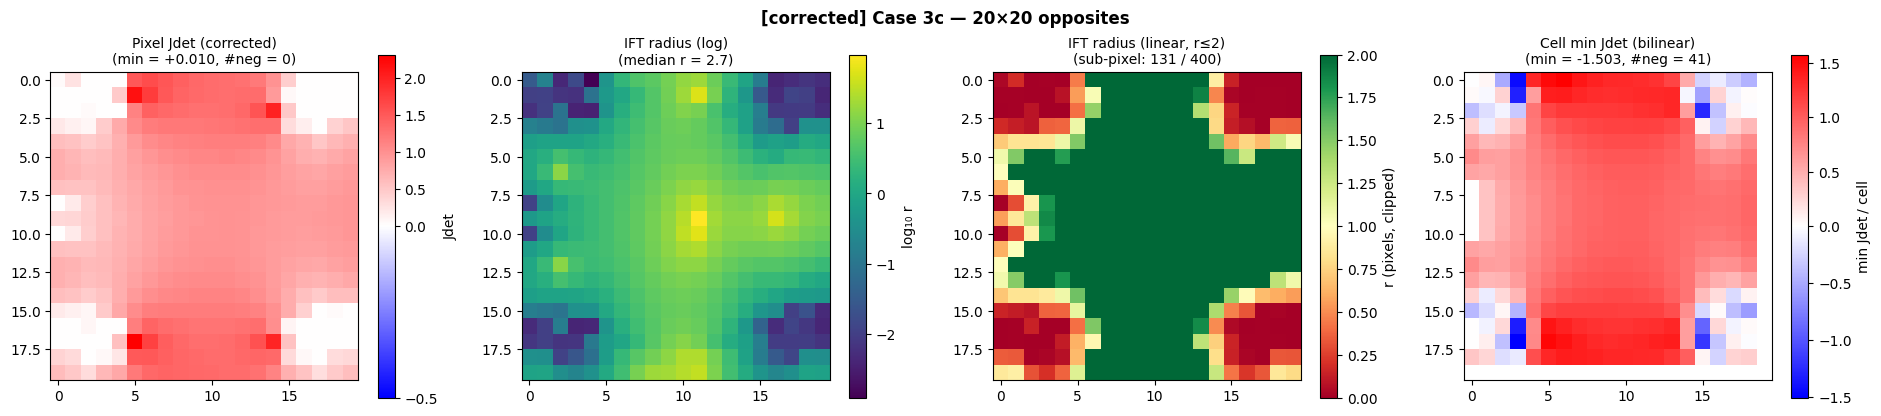

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_26.png


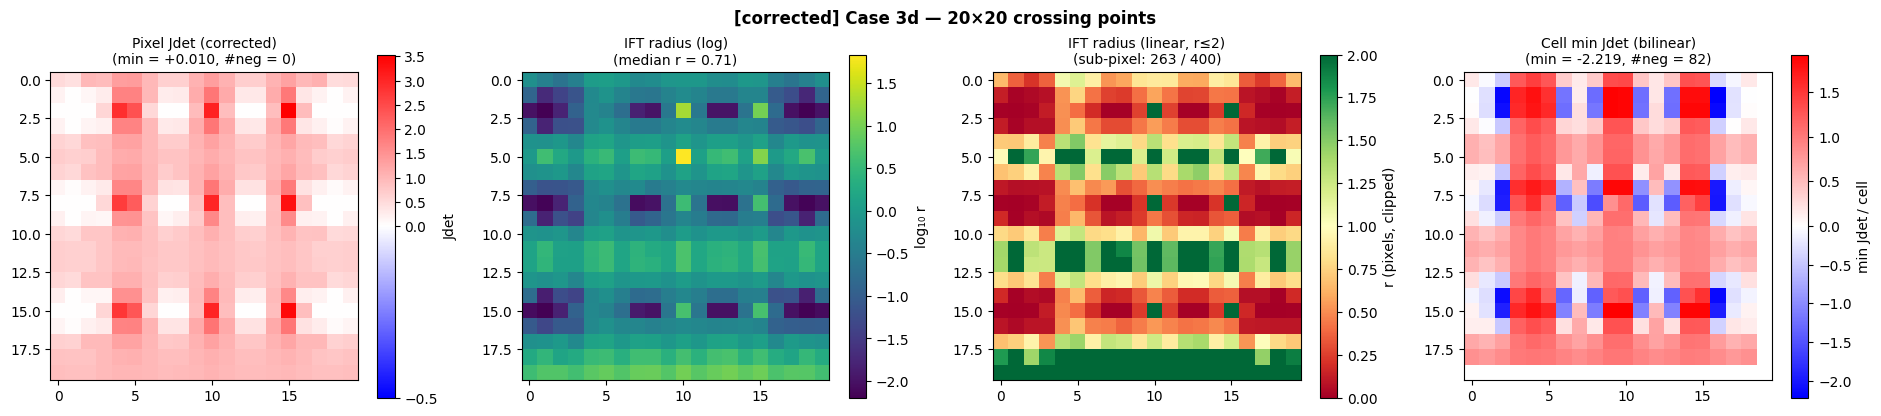

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_27.png


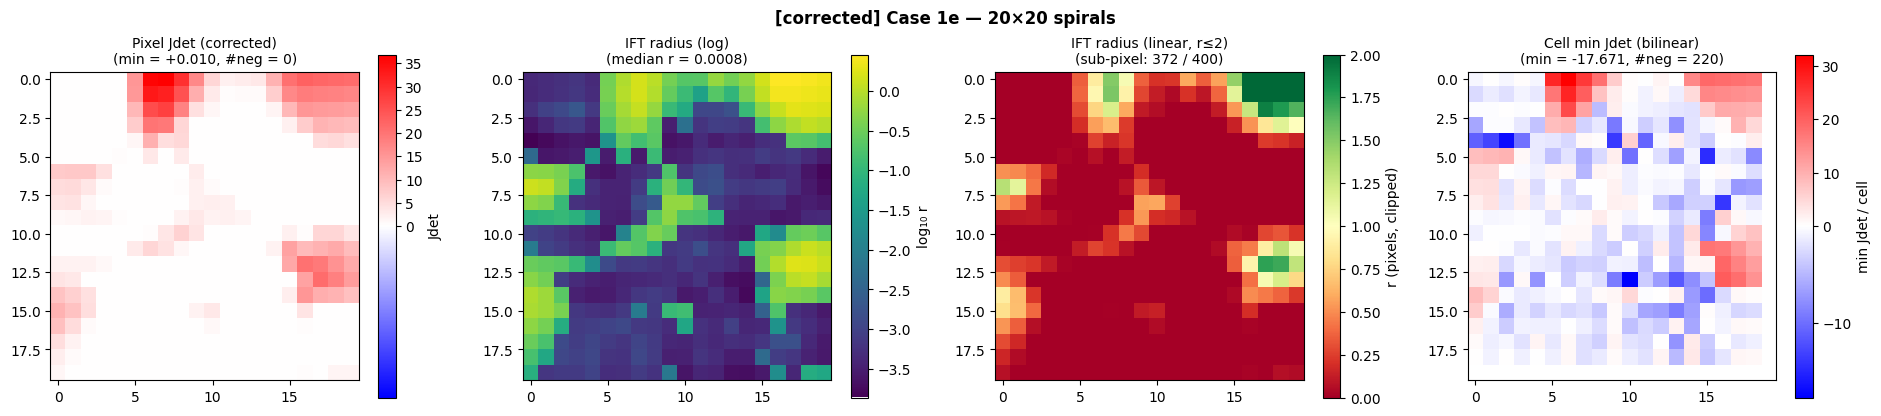

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_28.png


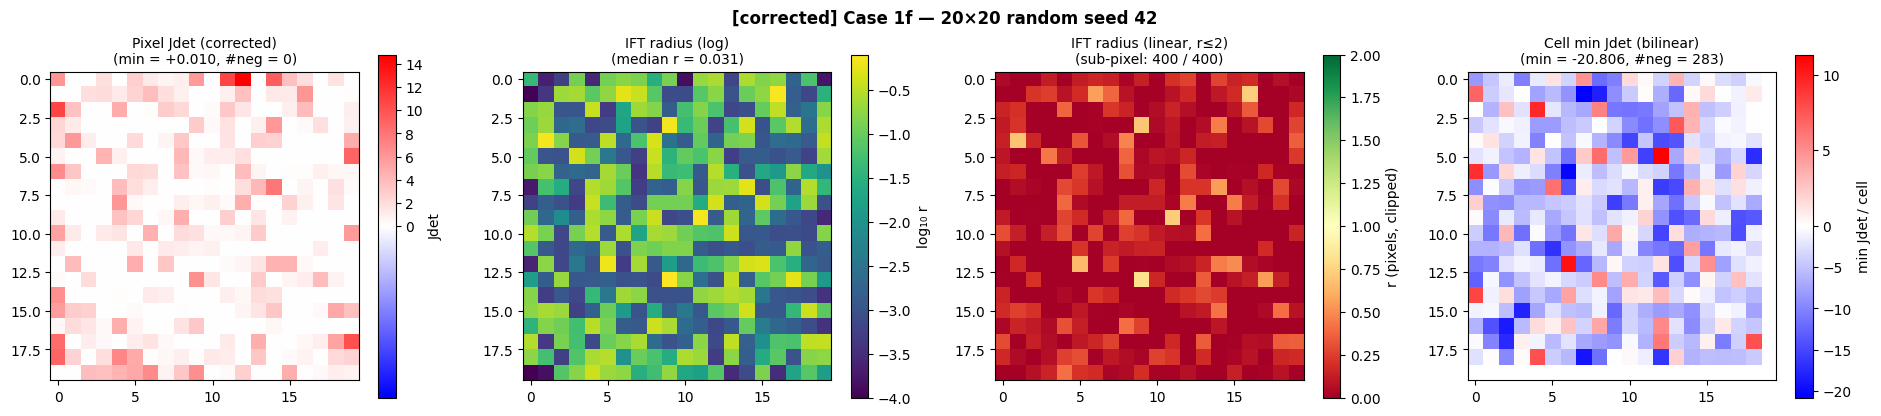

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_29.png


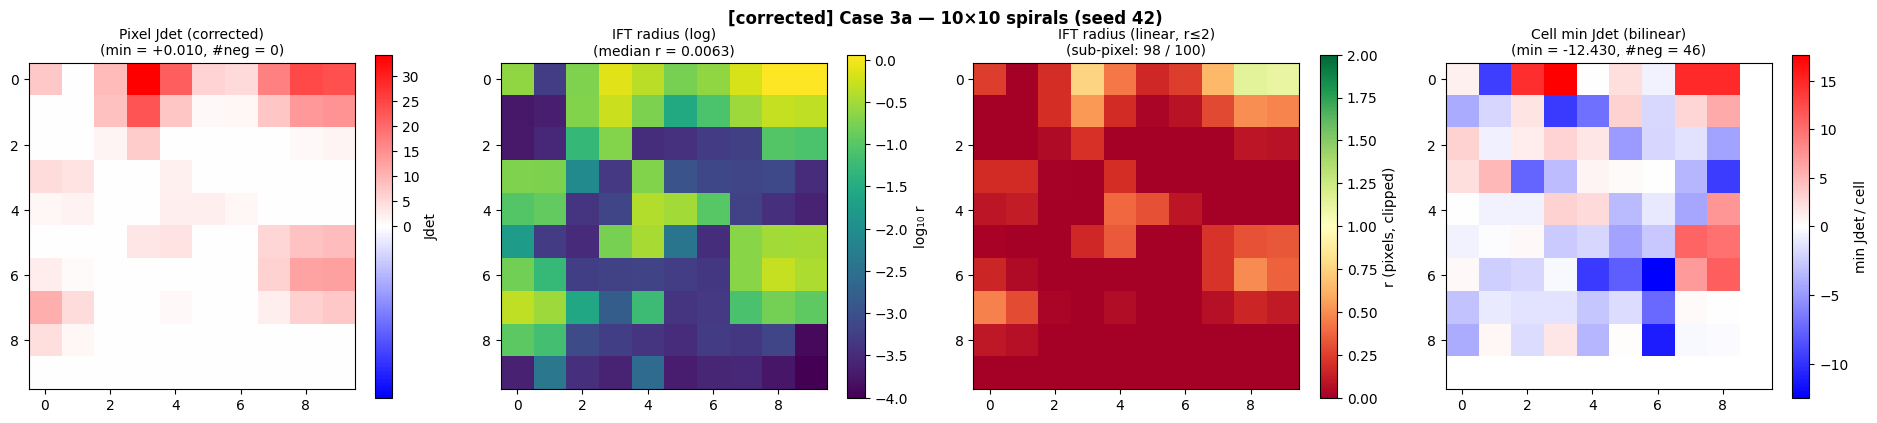

  [saved] ..\output\diagnostics\neighborhood-injectivity\figure_30.png


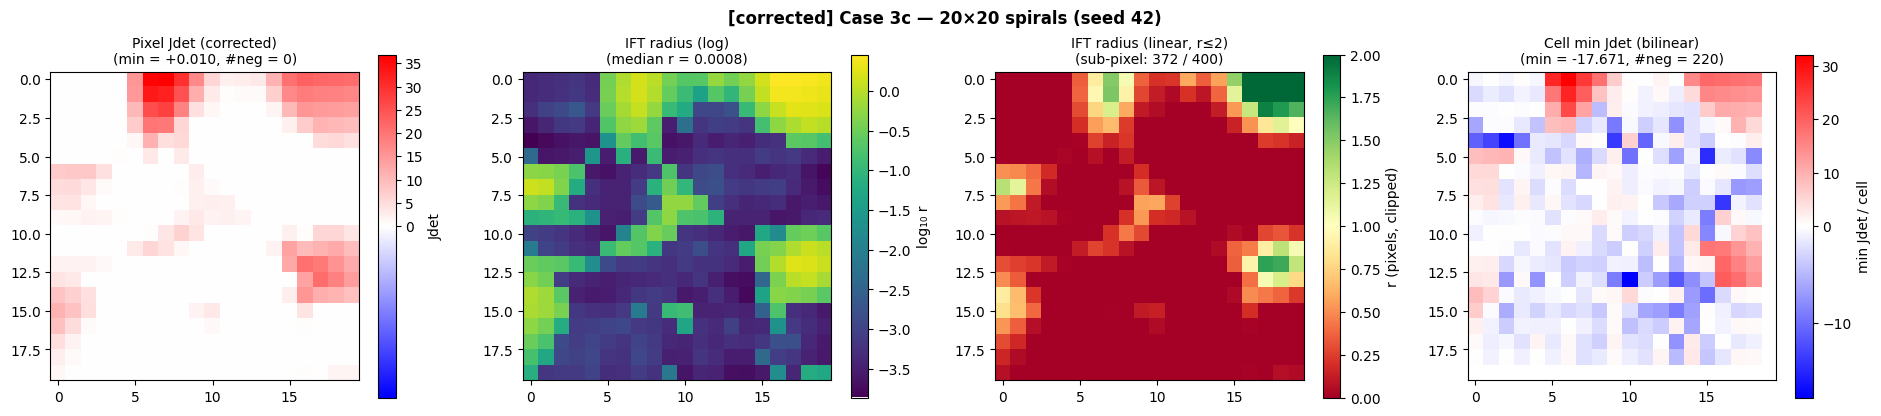

In [9]:
for rec in corrected_records:
    jac      = rec["jac"]
    ift_r    = rec["ift_r"]
    cell_pad = _pad_cell_map(rec["cell_min"])

    fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))

    im0 = axes[0].imshow(jac, cmap="bwr", norm=_jdet_norm(jac),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im0, ax=axes[0], label="Jdet")
    axes[0].set_title(f"Pixel Jdet (corrected)\n(min = {jac.min():+.3f}, #neg = {(jac <= 0).sum()})",
                      fontsize=10)

    r_safe = np.clip(ift_r, 1e-4, None)
    im1 = axes[1].imshow(np.log10(r_safe), cmap="viridis",
                         origin="upper", interpolation="nearest")
    plt.colorbar(im1, ax=axes[1], label="log\u2081\u2080 r")
    axes[1].set_title(f"IFT radius (log)\n(median r = {np.median(ift_r):.2g})",
                      fontsize=10)

    r_clip = np.clip(ift_r, 0.0, 2.0)
    r_norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)
    im2 = axes[2].imshow(r_clip, cmap="RdYlGn", norm=r_norm,
                         origin="upper", interpolation="nearest")
    plt.colorbar(im2, ax=axes[2], label="r (pixels, clipped)")
    axes[2].set_title(f"IFT radius (linear, r\u22642)\n(sub-pixel: {(ift_r < 1.0).sum()} / {ift_r.size})",
                      fontsize=10)

    cm = rec["cell_min"]
    im3 = axes[3].imshow(cell_pad, cmap="bwr", norm=_jdet_norm(cm),
                         origin="upper", interpolation="nearest")
    plt.colorbar(im3, ax=axes[3], label="min Jdet\u2009/ cell")
    axes[3].set_title(f"Cell min Jdet (bilinear)\n(min = {cm.min():+.3f}, #neg = {(cm <= 0).sum()})",
                      fontsize=10)

    fig.suptitle(f"[corrected] {rec['label']}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    show_and_save(OUTPUT_DIR)


---


In [10]:
def _fmt_cell(label, before, after):
    tag = " \u2713" if after == 0 and before > 0 else ""
    return f"{before:>6d} \u2192 {after:<6d}{tag}"

print(f"{'case':<32s} | {'pixel neg':<15s} | {'cell neg':<15s} | {'sub-pixel (r<1)':<18s}")
print("-" * 90)
for rec in corrected_records:
    print(f"{rec['label'][:32]:<32s} | "
          f"{_fmt_cell('', rec['n_neg_init'], rec['n_neg_final']):<15s} | "
          f"{_fmt_cell('', rec['n_cell_neg_init'], rec['n_cell_neg_final']):<15s} | "
          f"{_fmt_cell('', rec['n_sub_pixel_init'], rec['n_sub_pixel_final']):<18s}")

n_pixel_clean   = sum(1 for r in corrected_records if r["n_neg_final"] == 0)
n_cell_residual = sum(1 for r in corrected_records if r["n_neg_final"] == 0 and r["n_cell_neg_final"] > 0)
print(
    f"\n{n_pixel_clean}/{len(corrected_records)} cases have fully-positive pixel Jdet after correction.\n"
    f"Of those, {n_cell_residual} still have negative cell-min Jdet \u2014 sub-pixel folds that survived correction."
)


case                             | pixel neg       | cell neg        | sub-pixel (r<1)   
------------------------------------------------------------------------------------------
Case 1a — 10×10 crossing points  |      9 → 0      ✓ |     16 → 14     |     35 → 36       
Case 1b — 10×10 opposite         |      6 → 0      ✓ |      8 → 5      |     20 → 21       
Case 1c — 20×40 edges            |     32 → 1      |     61 → 65     |    246 → 250      
Case 1d — 20×40 crossing points  |    159 → 0      ✓ |    169 → 138    |    162 → 258      
Case 3a — 10×10 opposites        |     14 → 0      ✓ |     14 → 9      |     40 → 36       
Case 3b — 10×10 crossing points  |     18 → 0      ✓ |     24 → 26     |     84 → 88       
Case 3c — 20×20 opposites        |     34 → 0      ✓ |     42 → 41     |    133 → 131      
Case 3d — 20×20 crossing points  |     30 → 0      ✓ |     72 → 82     |    247 → 263      
Case 1e — 20×20 spirals          |    189 → 0      ✓ |    196 → 220    |    333 → 372

---


## Constraint-mode comparison

The default-mode correction above enforces only the pixel Jacobian constraint. The 2D solver also accepts `enforce_shoelace=True` (positive quad area) and `enforce_injectivity=True` (coordinate monotonicity + diagonal convexity) — these are *geometric* conditions that act on quads rather than pixel samples, so in principle they should close the sub-pixel gap that pixel-Jdet alone cannot. Below we re-run the corrector in all four modes and compare the three diagnostic counts in aggregate.


In [ ]:
INJECTIVITY_THRESHOLD = 0.3

MODES = {
    "Jac only":        dict(enforce_shoelace=False, enforce_injectivity=False),
    "Jac + Shoelace":  dict(enforce_shoelace=True,  enforce_injectivity=False),
    "Jac + Injectivity": dict(enforce_shoelace=False, enforce_injectivity=True,
                              injectivity_threshold=INJECTIVITY_THRESHOLD),
    "All constraints": dict(enforce_shoelace=True,  enforce_injectivity=True,
                            injectivity_threshold=INJECTIVITY_THRESHOLD),
}


def _run_mode(dvf, **kwargs):
    phi_corr = np.asarray(iterative_serial(dvf.copy(), verbose=0, **kwargs))
    if phi_corr.ndim == 4:
        phi_corr = np.stack([phi_corr[1, 0], phi_corr[2, 0]])
    jac_c  = np.squeeze(jacobian_det2D(phi_corr))
    ift_c  = ift_radius_2d(phi_corr)
    cell_c = cell_min_jdet_2d(phi_corr)
    return {
        "n_pix_neg":   int((jac_c <= 0).sum()),
        "n_cell_neg":  int((cell_c <= 0).sum()),
        "n_sub_pixel": int((ift_c < 1.0).sum()),
    }


mode_stats = {name: {"pix": 0, "cell": 0, "sub": 0, "cases_pix_clean": 0,
                     "cases_cell_clean": 0, "cases": 0}
              for name in MODES}
mode_stats["initial"] = {"pix": 0, "cell": 0, "sub": 0}

for rec in all_records:
    if int((rec["jac"] <= 0).sum()) == 0:
        continue
    label = rec["label"]
    mode_stats["initial"]["pix"]  += int((rec["jac"] <= 0).sum())
    mode_stats["initial"]["cell"] += int((rec["cell_min"] <= 0).sum())
    mode_stats["initial"]["sub"]  += int((rec["ift_r"] < 1.0).sum())
    print(f"\n{label}")
    for mode_name, kwargs in MODES.items():
        try:
            r = _run_mode(rec["dvf"], **kwargs)
        except Exception as e:
            print(f"  {mode_name:<20s}  FAILED: {type(e).__name__}: {e}")
            continue
        mode_stats[mode_name]["pix"]  += r["n_pix_neg"]
        mode_stats[mode_name]["cell"] += r["n_cell_neg"]
        mode_stats[mode_name]["sub"]  += r["n_sub_pixel"]
        mode_stats[mode_name]["cases"] += 1
        if r["n_pix_neg"] == 0:
            mode_stats[mode_name]["cases_pix_clean"] += 1
        if r["n_cell_neg"] == 0:
            mode_stats[mode_name]["cases_cell_clean"] += 1
        print(f"  {mode_name:<20s}  pix={r['n_pix_neg']:>4d}  "
              f"cell={r['n_cell_neg']:>4d}  sub-pixel={r['n_sub_pixel']:>4d}")


---


In [ ]:
init = mode_stats["initial"]
total_pix_area  = sum(rec["jac"].size     for rec in all_records if (rec["jac"] <= 0).any())
total_cell_area = sum(rec["cell_min"].size for rec in all_records if (rec["jac"] <= 0).any())

print(f"Aggregate over {sum(1 for r in all_records if (r['jac'] <= 0).any())} corrected cases "
      f"(pixel area {total_pix_area}, cell area {total_cell_area})\n")

print(f"{'Mode':<20s} | {'pixel neg':<12s} | {'cell neg':<12s} | {'sub-pixel (r<1)':<16s} | {'cases pix\u2713':<10s} | {'cases cell\u2713':<11s}")
print("-" * 100)
print(f"{'(initial)':<20s} | {init['pix']:>12d} | {init['cell']:>12d} | {init['sub']:>16d} | {'-':>10s} | {'-':>11s}")
for name in MODES:
    s = mode_stats[name]
    print(f"{name:<20s} | {s['pix']:>12d} | {s['cell']:>12d} | {s['sub']:>16d} | "
          f"{s['cases_pix_clean']:>3d}/{s['cases']:<3d}    | {s['cases_cell_clean']:>3d}/{s['cases']:<3d}")
print()
print("cases pix\u2713  = cases where every pixel Jdet > 0 after correction")
print("cases cell\u2713 = cases where every bilinear cell-min Jdet > 0 after correction")
print("              (sub-pixel injectivity certificate — the stronger diagnostic)")


---


In [11]:
import csv
from pathlib import Path

out_rows = []
for rec, r in zip(all_records, rows):
    out_rows.append({
        "case": rec["label"],
        "H": int(rec["jac"].shape[0]),
        "W": int(rec["jac"].shape[1]),
        "min_pixel_jdet":    round(float(rec["jac"].min()), 6),
        "min_cell_jdet":     round(float(rec["cell_min"].min()), 6),
        "median_ift_r":      round(float(np.median(rec["ift_r"])), 6),
        "n_pixels":          int(rec["jac"].size),
        "n_pixel_neg":       r["n_pixel_neg"],
        "n_cells":           r["n_cells"],
        "n_cell_neg":        r["n_cell_neg"],
        "n_hidden_fold":     r["n_hidden_fold"],
    })

cols = list(out_rows[0].keys())
path = Path(OUTPUT_DIR) / "results.csv"
with open(path, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=cols)
    w.writeheader()
    w.writerows(out_rows)
print(f"  [saved] {path}")

summary["n_cases"]            = len(out_rows)
summary["total_hidden_folds"] = int(sum(r["n_hidden_fold"] for r in rows))
summary["total_pixel_neg"]    = int(sum(r["n_pixel_neg"] for r in rows))
summary["total_cell_neg"]     = int(sum(r["n_cell_neg"] for r in rows))
save_summary_json(summary, OUTPUT_DIR)

  [saved] ..\output\diagnostics\neighborhood-injectivity\results.csv
  [saved] ..\output\diagnostics\neighborhood-injectivity\summary.json


---
## Interpretation

- **`n_pixel_neg`**: number of pixels with $J_{\det} \leq 0$ measured by central differences.  This is what the correction pipeline currently targets.
- **`n_cell_neg`**: number of quads where the bilinear interpolant's Jdet dips $\leq 0$ somewhere inside the cell.  A *cell-level* count of sub-pixel folds.
- **`n_hidden_fold`**: number of quads whose four corner pixels all have positive Jdet **yet** the bilinear interpolant has negative Jdet in the cell interior.  These are folds the standard pixel-Jdet check cannot see — classical inverse-function-theorem gives neighbourhoods too small to cover these cells.
- **`median_ift_r`**: per-case median of the quantitative-IFT radius lower bound.  Values $\gg 1$ pixel indicate the IFT guarantees injectivity well beyond the sample neighbourhood; values $\ll 1$ indicate the field is curvy or near-singular and the guarantee is effectively pointwise only.

For a paper: `n_hidden_fold` is the strongest empirical argument that pixel-Jdet alone is insufficient as an injectivity criterion on discrete grids.

## Paper summaries

Short, computation-focused digest of each reference — what the paper actually proves and which line of this notebook it is justifying.

**[1] Rudin, *Principles of Mathematical Analysis* (1976), Thm. 9.24 — classical IFT.**
The textbook statement: if $\phi: \mathbb{R}^n \to \mathbb{R}^n$ is $C^1$ and $D\phi(x_0)$ is invertible, then $\phi$ is a $C^1$ diffeomorphism on *some* open neighbourhood $U \ni x_0$. Purely qualitative — the proof shows $U$ exists but gives no handle on its size or shape. This is the baseline result that our radius map $r(x)$ is quantifying: "$r(x)$ big" just means Rudin's $U$ can be taken as a ball of radius $\approx r(x)$.

**[2] Krantz & Parks, *The Implicit Function Theorem* (2002), §3.2 — quantitative IFT.**
Collects the constructive/quantitative refinements of the IFT. The proof we use is the Banach-fixed-point one: on any ball $B(x_0, r)$ where the affine remainder $\|D\phi(x) - A\|$ is bounded by $1/(2L)$ with $L = \|A^{-1}\|$, $\phi$ is a diffeomorphism and covers a ball of radius $r/(2L)$ in the image. Plugging in the two DVF-specific bounds — $L = 1/\sigma_{\min}(I + \nabla u)$ from the smallest singular value, and $\|D\phi(x) - A\| \leq \|\nabla^2 u\|\cdot r$ from the mean-value theorem applied to $\nabla u$ — and solving for the largest $r$ that still satisfies the hypothesis gives exactly the per-pixel formula $r \gtrsim \sigma_{\min}/(2\|\nabla^2 u\|)$ implemented in `ift_radius_2d`.

**[3] Karaçalı & Davatzikos, IEEE TMI 2004 — topology-preserving displacement fields.**
Image-registration paper that makes the discrete-injectivity gap explicit and operational. They demonstrate that enforcing $J_{\det}(x_i) > 0$ at sample sites $x_i$ is **insufficient** — inter-sample folds occur even when every pixel-Jdet is positive — and derive a set of voxel-local conditions (signed tetrahedral-volume sums inside each voxel cube) that are both necessary and sufficient for the *continuous* trilinearly-interpolated field to be injective. Our 2D per-cell min-Jdet is the bilinear specialisation of exactly that idea: certify injectivity of the continuous interpolant, not just of its samples.

**[4] Choi & Lee, *Graphical Models* 2000 — injectivity of uniform cubic B-spline DVFs.**
Derives explicit, closed-form sufficient conditions on control-point displacements under which 2D/3D uniform cubic B-spline deformations are globally injective; the conditions are bounds on the per-axis displacement magnitude relative to the grid spacing. Widely cited as the canonical reference for "sample-point Jdet positivity is weaker than continuous-map injectivity on a discrete grid," and the template for later work (including [3]) that expands the analysis to bilinear/trilinear interpolants. Motivates why we separately compute `cell_min_jdet_2d` rather than relying on `jacobian_det2D` alone.

**[5] Ciarlet, *The FEM for Elliptic Problems* (1978/2002 reprint), §4.3 — isoparametric cell invertibility.**
Classical FEM reference for the algebraic structure of isoparametric-element Jacobians. On the 2D bilinear reference square with shape functions $\{(1-\alpha)(1-\beta), \alpha(1-\beta), (1-\alpha)\beta, \alpha\beta\}$, a direct expansion shows $J_{\det}(\alpha,\beta)$ is **biaffine** — i.e. affine in $\alpha$ for each fixed $\beta$ and vice versa. A biaffine function on $[0,1]^2$ attains its extrema at the corners, hence $\min_{\text{cell}} J_{\det} = \min_{\text{4 corners}} J_{\det}$, which is exactly the closed form in `cell_min_jdet_2d`. No numerical minimisation over the cell interior is needed.

**[6] Ushakova, *SIAM J. Sci. Comput.* 2001 — nondegeneracy of 3D trilinear cells.**
3D analog of [5]. The trilinear Jdet on $[0,1]^3$ is cubic (no longer biaffine), so the 2D "min at corners" shortcut does **not** generalise directly — the paper derives the correct algebraic nondegeneracy conditions and a closed-form volume expression for a hexahedral cell. Relevant if we extend this notebook's cell-min diagnostic to 3D: one needs Ushakova's sufficient conditions rather than just evaluating the eight hex corners.


---
## References

**Inverse function theorem and its quantitative form.**

[1] W. Rudin, *Principles of Mathematical Analysis*, 3rd ed., McGraw-Hill, 1976. Chapter 9, Theorem 9.24 (classical IFT; existence of a neighbourhood $U$ but no quantitative bound).

[2] S. G. Krantz and H. R. Parks, *The Implicit Function Theorem: History, Theory, and Applications*, Birkhäuser, 2002. Chapter 3, §3.2 derives the explicit radius bound used here: if $A = D\phi(x_0)$, $L = \|A^{-1}\|$, and $\|D\phi(x) - A\| \leq 1/(2L)$ on $B(x_0, r)$, then $\phi$ is a diffeomorphism on $B(x_0, r)$ and its image contains $B(\phi(x_0), r/(2L))$. Substituting $L = 1/\sigma_{\min}(I + \nabla u)$ and $\|D\phi(x) - A\| \leq \|\nabla^2 u\| \cdot \|x - x_0\|$ gives the per-pixel radius formula.

**Discrete-grid injectivity in image registration.**

[3] B. Karaçalı and C. Davatzikos, "Estimating topology preserving and smooth displacement fields," *IEEE Transactions on Medical Imaging*, vol. 23, no. 7, pp. 868–880, 2004. Formulates and enforces topology preservation (positive Jacobian) on a discrete grid; motivates why pointwise Jdet is not sufficient.

[4] Y. Choi and S. Lee, "Injectivity conditions of 2D and 3D uniform cubic B-spline functions," *Graphical Models*, vol. 62, no. 6, pp. 411–427, 2000. Derives explicit sufficient conditions on control-point displacements for B-spline DVFs to be globally injective — the primary reference for "positive sample Jdet does not imply continuous-map injectivity on a discrete grid."

**Bilinear / isoparametric cell invertibility (closed-form cell-Jdet).**

[5] P. G. Ciarlet, *The Finite Element Method for Elliptic Problems*, SIAM Classics in Applied Mathematics 40, 2002 (reprint of 1978 original, North-Holland). §4.3 analyses invertibility of bilinear/bi-$n$-linear isoparametric maps on reference cells; the biaffine structure of the Jdet on a 2D reference square is a classical result from this framework.

[6] O. V. Ushakova, "Conditions of nondegeneracy of three-dimensional cells. A formula of a volume of cells," *SIAM Journal on Scientific Computing*, vol. 23, no. 4, pp. 1274–1290, 2001. The 3D trilinear counterpart of the biaffine cell-Jdet closed-form used here; gives explicit nondegeneracy conditions for hexahedral cells.
